# Statistical Analysis
Statistical analysis involves summarizing and describing the features of the dataset. Here are the key metrics we will compute for the Population data:

Mean: The average population over the years.
Median: The middle value of the population data.
Standard Deviation: A measure of the population's spread around the mean.
Variance: The square of the standard deviation.
Min and Max: The smallest and largest population values.
Skewness: Measure of data asymmetry.
Kurtosis: Measure of data concentration around the mean.


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis

# Load the filtered dataset
file_path = "China_Population_Filtered.xlsx"
df = pd.read_excel(file_path)

# Calculate statistical metrics
mean_population = df['Population'].mean()
median_population = df['Population'].median()
std_dev_population = df['Population'].std()
variance_population = df['Population'].var()
min_population = df['Population'].min()
max_population = df['Population'].max()
skewness_population = skew(df['Population'])
kurtosis_population = kurtosis(df['Population'])

# Print results
print("Statistical Analysis of China's Population Data:")
print(f"Mean Population: {mean_population:.2f}")
print(f"Median Population: {median_population:.2f}")
print(f"Standard Deviation: {std_dev_population:.2f}")
print(f"Variance: {variance_population:.2f}")
print(f"Minimum Population: {min_population}")
print(f"Maximum Population: {max_population}")
print(f"Skewness: {skewness_population:.2f}")
print(f"Kurtosis: {kurtosis_population:.2f}")


Statistical Analysis of China's Population Data:
Mean Population: 1040878976.96
Median Population: 1077770523.00
Standard Deviation: 286828903.87
Variance: 82270820096714000.00
Minimum Population: 543979233
Maximum Population: 1425893465
Skewness: -0.27
Kurtosis: -1.32


# Hypothesis Testing 
Hypothesis:
H₀ (Null Hypothesis): The population mean is equal to the value we expect (e.g., the mean population in 1950).
H₁ (Alternative Hypothesis): The population mean is not equal to the value we expect.
We will perform a one-sample t-test to check if the population mean differs significantly from a given value (for instance, the population mean in 1950). The t-test is ideal for comparing the sample mean with a known value when the sample size is small to medium.

In [2]:
# Import necessary libraries for hypothesis testing
from scipy.stats import ttest_1samp

# Assuming we want to test if the population mean is equal to the mean of population in 1950
population_1950 = df[df['Year'] == 1950]['Population'].values[0]

# Perform one-sample t-test
t_statistic, p_value = ttest_1samp(df['Population'], population_1950)

# Set significance level
alpha = 0.05

# Print the results
print(f"T-statistic: {t_statistic:.2f}")
print(f"P-value: {p_value:.4f}")

# Decision based on p-value
if p_value < alpha:
    print("Reject H₀: The population mean is significantly different from the population in 1950.")
else:
    print("Fail to reject H₀: There is no significant difference in population mean compared to 1950.")


T-statistic: 14.80
P-value: 0.0000
Reject H₀: The population mean is significantly different from the population in 1950.


# Plotting of Data

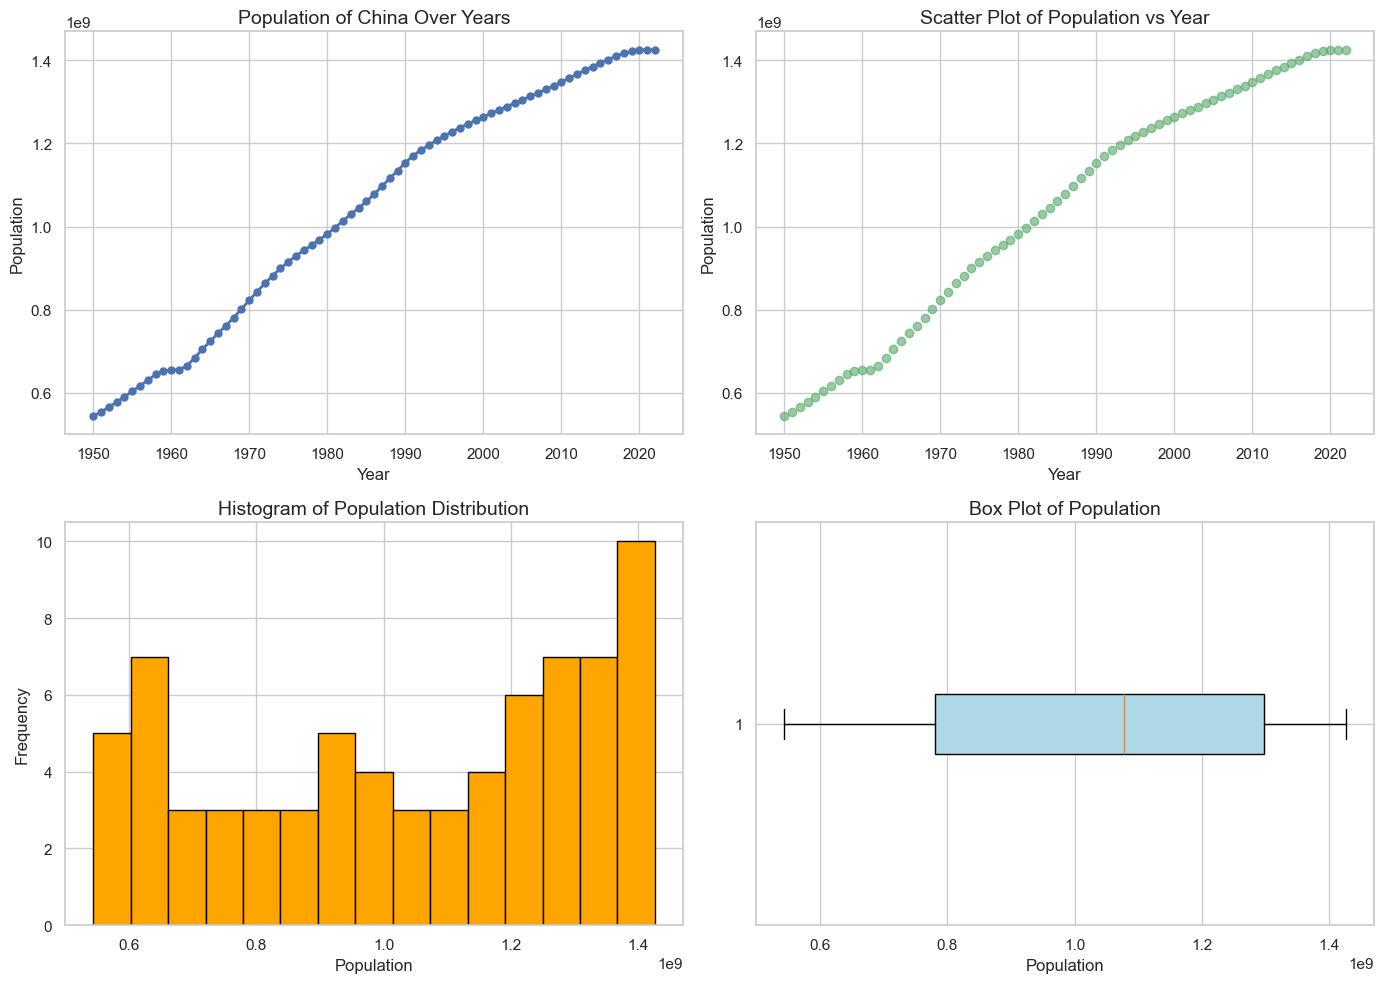

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set(style="whitegrid")

# Create a figure and axis
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# Line Plot: Population over years
ax[0, 0].plot(df['Year'], df['Population'], marker='o', color='b', linestyle='-', linewidth=2, markersize=5)
ax[0, 0].set_title('Population of China Over Years', fontsize=14)
ax[0, 0].set_xlabel('Year', fontsize=12)
ax[0, 0].set_ylabel('Population', fontsize=12)

# Scatter Plot: Population vs Year
ax[0, 1].scatter(df['Year'], df['Population'], color='g', alpha=0.6)
ax[0, 1].set_title('Scatter Plot of Population vs Year', fontsize=14)
ax[0, 1].set_xlabel('Year', fontsize=12)
ax[0, 1].set_ylabel('Population', fontsize=12)

# Histogram: Distribution of Population
ax[1, 0].hist(df['Population'], bins=15, color='orange', edgecolor='black')
ax[1, 0].set_title('Histogram of Population Distribution', fontsize=14)
ax[1, 0].set_xlabel('Population', fontsize=12)
ax[1, 0].set_ylabel('Frequency', fontsize=12)

# Box Plot: Population distribution
ax[1, 1].boxplot(df['Population'], vert=False, patch_artist=True, boxprops=dict(facecolor='lightblue', color='black'))
ax[1, 1].set_title('Box Plot of Population', fontsize=14)
ax[1, 1].set_xlabel('Population', fontsize=12)

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()


# Linear Regression Model For Prediction
Linear regression helps us model the relationship between an independent variable (Year) and a dependent variable (Population). In this case, we want to predict China's population in the coming years using the historical data.

Steps to Build the Model:
Prepare Data: Extract relevant columns (Year and Population).
Train-Test Split: Split the data into training and testing sets.
Linear Regression: Use Scikit-learn to fit a linear regression model to the data.
Prediction: Use the trained model to predict future population values.


In [6]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score


# Prepare the data
X = df[['Year']]  # Independent variable (Year)
y = df['Population']  # Dependent variable (Population)

# Create a pipeline with PolynomialFeatures and LinearRegression
degree = 2  # You can try other degrees like 3 or 4
model = make_pipeline(PolynomialFeatures(degree), LinearRegression())

# Train the model
model.fit(X, y)

# Predict population on the training data
y_pred_train = model.predict(X)

# Evaluate the model
mse_train = mean_squared_error(y, y_pred_train)
r2_train = r2_score(y, y_pred_train)

# Print evaluation metrics
print(f"Mean Squared Error: {mse_train:.2f}")
print(f"R-squared: {r2_train:.2f}")

# Get current population (last available year's population)
current_year = df['Year'].max()
current_population = df[df['Year'] == current_year]['Population'].values[0]
print(f"Current Population in {current_year}: {current_population:.0f}")

# Predict future population 
future_years = pd.DataFrame({'Year': [2024, 2030, 2035 , 2040 , 2043, 2050]})
future_population = model.predict(future_years)

# Print predictions for future years
for year, pop in zip(future_years['Year'], future_population):
    print(f"Predicted Population for {year}: {pop:.0f}")


Mean Squared Error: 429075203743658.88
R-squared: 0.99
Current Population in 2022: 1425887337
Predicted Population for 2024: 1469710811
Predicted Population for 2030: 1510597282
Predicted Population for 2035: 1540253637
Predicted Population for 2040: 1565895716
Predicted Population for 2043: 1579354111
Predicted Population for 2050: 1605137044


# Regression Model

Mean Squared Error: 429075203743658.88
R-squared: 0.99
Current Population in 2022: 1425887337
Predicted Population for 2024: 1469710811
Predicted Population for 2030: 1510597282
Predicted Population for 2035: 1540253637
Predicted Population for 2040: 1565895716
Predicted Population for 2043: 1579354111
Predicted Population for 2050: 1605137044


c:\Users\nazir\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


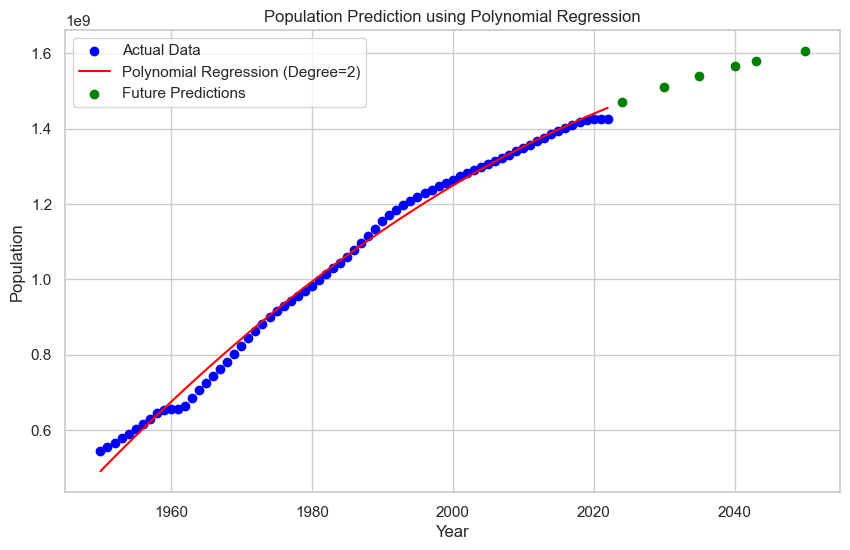

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare the data
X = df[['Year']]  # Independent variable (Year)
y = df['Population']  # Dependent variable (Population)

# Create a pipeline with PolynomialFeatures and LinearRegression
degree = 2  # Polynomial degree (quadratic in this case)
model = make_pipeline(PolynomialFeatures(degree), LinearRegression())

# Train the model
model.fit(X, y)

# Predict population on the training data
y_pred_train = model.predict(X)

# Evaluate the model
mse_train = mean_squared_error(y, y_pred_train)
r2_train = r2_score(y, y_pred_train)

# Print evaluation metrics
print(f"Mean Squared Error: {mse_train:.2f}")
print(f"R-squared: {r2_train:.2f}")

# Get current population (last available year's population)
current_year = df['Year'].max()
current_population = df[df['Year'] == current_year]['Population'].values[0]
print(f"Current Population in {current_year}: {current_population:.0f}")

# Predict future population for selected years
future_years = pd.DataFrame({'Year': [2024, 2030, 2035, 2040, 2043, 2050]})
future_population = model.predict(future_years)

# Print predictions for future years
for year, pop in zip(future_years['Year'], future_population):
    print(f"Predicted Population for {year}: {pop:.0f}")

# Plotting the data and the polynomial regression line
plt.figure(figsize=(10, 6))

# Plot the original data points
plt.scatter(df['Year'], df['Population'], color='blue', label='Actual Data')

# Plot the predicted polynomial regression line
years_range = np.linspace(df['Year'].min(), df['Year'].max(), 100).reshape(-1, 1)  # Create a range of years
predicted_population = model.predict(years_range)  # Get predictions for the range of years

plt.plot(years_range, predicted_population, color='red', label=f'Polynomial Regression (Degree={degree})')

# Highlight the future predictions
plt.scatter(future_years['Year'], future_population, color='green', label='Future Predictions')

# Add labels and title
plt.title('Population Prediction using Polynomial Regression')
plt.xlabel('Year')
plt.ylabel('Population')
plt.legend()

# Show plot
plt.grid(True)
plt.show()


# Confidence Interval

c:\Users\nazir\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
c:\Users\nazir\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


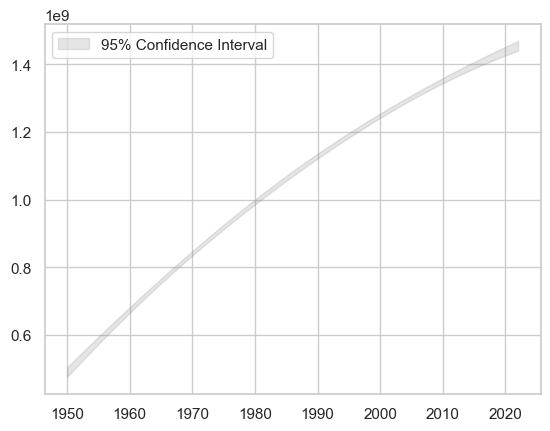


Confidence Intervals:
Year 1950: Predicted 490153992 (95% CI: 475945802 to 504362182)
Year 1957: Predicted 625386638 (95% CI: 615924153 to 634849122)
Year 1965: Predicted 752126269 (95% CI: 745178385 to 759074152)
Year 1972: Predicted 870372885 (95% CI: 863794713 to 876951056)
Year 1979: Predicted 980126486 (95% CI: 973068108 to 987184864)
Year 1986: Predicted 1081387073 (95% CI: 1074087039 to 1088687106)
Year 1994: Predicted 1174154644 (95% CI: 1167144502 to 1181164787)
Year 2001: Predicted 1258429201 (95% CI: 1251877563 to 1264980840)
Year 2008: Predicted 1334210744 (95% CI: 1327120431 to 1341301056)
Year 2015: Predicted 1401499271 (95% CI: 1391654867 to 1411343675)


In [8]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

def calculate_confidence_interval(model, X, y, X_predict, confidence_level=0.95):
    """
    Calculate confidence intervals for polynomial regression predictions
    
    Parameters:
    - model: Trained polynomial regression model
    - X: Original input features
    - y: Original target values
    - X_predict: Features to predict
    - confidence_level: Confidence level for interval
    
    Returns:
    - Predictions with confidence intervals
    """
    # Predict values
    y_pred = model.predict(X_predict)
    
    # Compute standard error
    # Predict on training data
    y_pred_train = model.predict(X)
    
    # Calculate residuals
    residuals = y - y_pred_train
    
    # Degrees of freedom
    n = len(X)
    p = X.shape[1]  # Number of features
    
    # Standard error of the regression
    std_error = np.sqrt(np.sum(residuals**2) / (n - p))
    
    # Polynomial features transformation
    poly_features = model.named_steps['polynomialfeatures']
    X_poly = poly_features.transform(X)
    X_predict_poly = poly_features.transform(X_predict)
    
    # Compute standard error of prediction
    linear_model = model.named_steps['linearregression']
    
    # Compute the variance-covariance matrix of the coefficients
    MSE = np.sum(residuals**2) / (n - p)
    var_b = MSE * np.linalg.inv(np.dot(X_poly.T, X_poly)).diagonal()
    
    # Standard error of predicted values
    se = np.sqrt(np.sum((X_predict_poly @ np.linalg.inv(X_poly.T @ X_poly) * X_predict_poly), axis=1) * MSE)
    
    # T-value for confidence interval
    t_value = stats.t.ppf((1 + confidence_level) / 2, df=n-p)
    
    # Confidence intervals
    lower_bound = y_pred - t_value * se
    upper_bound = y_pred + t_value * se
    
    return y_pred, lower_bound, upper_bound

# Assuming you have already created your model and plotted the regression line
# This is how you would add confidence intervals

# Example usage:
# Prepare your prediction range
X_predict = np.linspace(df['Year'].min(), df['Year'].max(), 100).reshape(-1, 1)

# Calculate confidence intervals
y_pred, lower_bound, upper_bound = calculate_confidence_interval(model, X, y, X_predict)

# Plot confidence intervals
plt.fill_between(
    X_predict.flatten(), 
    lower_bound, 
    upper_bound, 
    color='gray', 
    alpha=0.2, 
    label='95% Confidence Interval'
)

plt.legend()
plt.show()

# If you want to print out specific confidence intervals
print("\nConfidence Intervals:")
for year, pred, low, high in zip(X_predict.flatten()[::10], y_pred[::10], lower_bound[::10], upper_bound[::10]):
    print(f"Year {year:.0f}: Predicted {pred:.0f} (95% CI: {low:.0f} to {high:.0f})")

# Confidense Interval of Slope

In [9]:
import numpy as np
import scipy.stats as stats

# Fit the model as usual
model.fit(X, y)

# Extract the coefficients
coefficients = model.named_steps['linearregression'].coef_

# Get predictions
y_pred_train = model.predict(X)

# Calculate residuals
residuals = y - y_pred_train

# Calculate the standard error of the slope (assuming 2nd degree polynomial)
# For higher degrees, this can be extended to more terms.
X_design_matrix = model.named_steps['polynomialfeatures'].fit_transform(X)  # Design matrix

# Residual sum of squares
rss = np.sum(residuals ** 2)

# Degrees of freedom = n - number of coefficients
n = len(y)
p = X_design_matrix.shape[1]  # number of coefficients
df = n - p

# Variance of residuals
residual_variance = rss / df

# Calculate the covariance matrix for the coefficients
cov_matrix = np.linalg.inv(X_design_matrix.T.dot(X_design_matrix)) * residual_variance

# Standard error of the coefficients
standard_errors = np.sqrt(np.diag(cov_matrix))

# Get the standard error for the slope (linear term) which is the 2nd coefficient in the model
slope_index = 1  # Assuming degree 2 polynomial (this will be the linear term)
slope = coefficients[slope_index]
slope_se = standard_errors[slope_index]

# Calculate t-value for a 95% confidence interval
t_value = stats.t.ppf(1 - 0.025, df)  # Two-tailed t-test, 95% confidence level

# Calculate confidence interval
lower_bound = slope - t_value * slope_se
upper_bound = slope + t_value * slope_se

print(f"Slope (Linear Term): {slope:.4f}")
print(f"95% Confidence Interval for the Slope: [{lower_bound:.4f}, {upper_bound:.4f}]")


Slope (Linear Term): 332291950.9845
95% Confidence Interval for the Slope: [282889726.4543, 381694175.5146]
